# 🫀 ECG Analyzer + LLM-based Clinical Explanation System

**Dataset:** MIT-BIH Arrhythmia Dataset (Kaggle)

**Pipeline:**
1. Setup & Installations
2. Data Loading & Preprocessing
3. ECG Model Training (1D CNN-LSTM)
4. Evaluation (Classification)
5. RAG Pipeline (FAISS + Sentence Transformers)
6. LLM Pipelines (Base / Prompt-Engineered / RAG)
7. Fine-Tuning with QLoRA (PEFT)
8. LLM Evaluation (BLEU / ROUGE)
9. Hallucination & Error Analysis
10. Gradio UI Demo


## 1. 🔧 Setup & Installations

In [1]:
# =========================
# FINAL INSTALL (PYTHON 3.12 SAFE)
# =========================

!pip install -q --upgrade pip

# ✅ Use compatible numpy (DO NOT force 1.24.4)
!pip install -q numpy scipy

# Core ML
!pip install -q torch torchvision torchaudio

# FAISS (safe version)
!pip install -q faiss-cpu

# HuggingFace ecosystem
!pip install -q transformers accelerate datasets evaluate

# PEFT stack
!pip install -q peft bitsandbytes

# Embeddings
!pip install -q sentence-transformers

# Metrics + utils
!pip install -q rouge-score nltk scikit-learn pandas matplotlib seaborn tqdm

# UI
!pip install -q gradio

print("✅ FINAL INSTALL SUCCESS (Python 3.12 compatible)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ FINAL INSTALL SUCCESS (Python 3.12 compatible)


In [2]:
import torch
import transformers
import faiss

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("FAISS loaded successfully")

Torch: 2.10.0+cu128
Transformers: 5.0.0
FAISS loaded successfully


In [3]:
# Standard imports
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# NLTK for BLEU
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print('✅ Imports complete and seeds set.')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Imports complete and seeds set.


## 2. 📦 Data Loading & Preprocessing

In [4]:
# ===============================
# Dataset Download / Setup
# ===============================
import os

DATA_DIR = './heartbeat'
os.makedirs(DATA_DIR, exist_ok=True)

# --- Option A: Kaggle CLI (works on Colab & local if kaggle.json exists) ---
if not os.path.exists(os.path.join(DATA_DIR, 'mitbih_train.csv')):
    try:
        # Try Colab file upload first (no-op outside Colab)
        try:
            from google.colab import files
            print("📁 Upload your kaggle.json (skip if already present):")
            uploaded = files.upload()
            if 'kaggle.json' in uploaded:
                os.makedirs('/root/.kaggle', exist_ok=True)
                with open('/root/.kaggle/kaggle.json', 'wb') as kf:
                    kf.write(uploaded['kaggle.json'])
                os.chmod('/root/.kaggle/kaggle.json', 0o600)
                print("✅ Kaggle credentials configured via upload")
        except Exception:
            pass  # Not in Colab — rely on existing ~/.kaggle/kaggle.json

        # Download via kaggle CLI
        os.system(f'kaggle datasets download -d shayanfazeli/heartbeat --unzip -p {DATA_DIR}')
        print(f"✅ Dataset downloaded to {DATA_DIR}")

    except Exception as e:
        print(f"⚠️  Kaggle download failed: {e}")
        print("   → Place mitbih_train.csv and mitbih_test.csv inside './heartbeat/' manually.")
else:
    print(f"✅ Dataset already present in {DATA_DIR}")

print("Files:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "directory not found")


📁 Upload your kaggle.json (skip if already present):


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured via upload
✅ Dataset downloaded to ./heartbeat
Files: ['ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv']


In [5]:
import os
DATA_DIR = './heartbeat'
print(os.listdir(DATA_DIR))


['ptbdb_normal.csv', 'mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv']


In [6]:
# ─────────────────────────────────────────────
# OPTION B: Manual upload (fallback)
# ─────────────────────────────────────────────
# Uncomment below if you want to upload manually

# from google.colab import files
# os.makedirs('./heartbeat', exist_ok=True)
# print('Upload mitbih_train.csv and mitbih_test.csv:')
# uploaded = files.upload()
# for fname in uploaded:
#     os.rename(fname, f'./heartbeat/{fname}')

In [7]:
# ─────────────────────────────────────────────
# Load MIT-BIH CSV Files
# ─────────────────────────────────────────────
DATA_DIR = './heartbeat'

train_path = os.path.join(DATA_DIR, 'mitbih_train.csv')
test_path  = os.path.join(DATA_DIR, 'mitbih_test.csv')

print('Loading training data...')
df_train = pd.read_csv(train_path, header=None)
print('Loading test data...')
df_test  = pd.read_csv(test_path,  header=None)

print(f'\n📊 Train shape: {df_train.shape}')
print(f'📊 Test  shape: {df_test.shape}')
print('\nFirst 5 rows of training data:')
df_train.head()

Loading training data...
Loading test data...

📊 Train shape: (87554, 188)
📊 Test  shape: (21892, 188)

First 5 rows of training data:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


📈 Training class distribution:
  Class 0 (Normal Beat): 72,471 samples (82.8%)
  Class 1 (Supraventricular Ectopy): 2,223 samples (2.5%)
  Class 2 (Ventricular Ectopy): 5,788 samples (6.6%)
  Class 3 (Fusion Beat): 641 samples (0.7%)
  Class 4 (Unclassifiable Beat): 6,431 samples (7.3%)


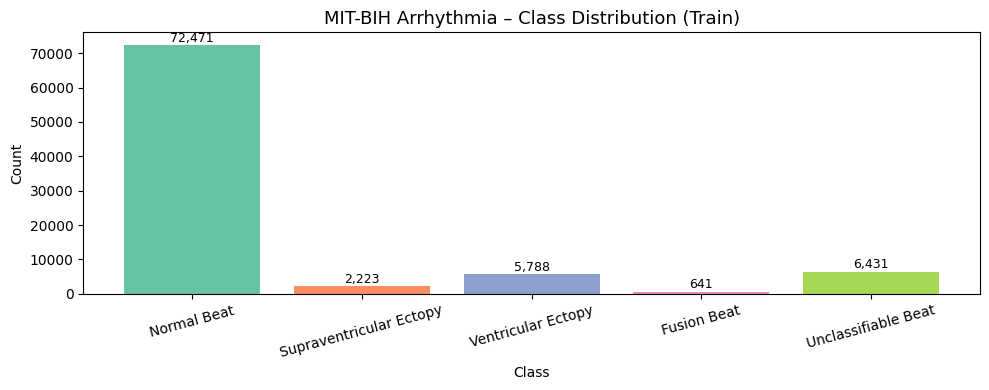

In [8]:
# ─────────────────────────────────────────────
# Understand the dataset structure
# ─────────────────────────────────────────────

# MIT-BIH has 188 columns: 187 signal features + 1 label column
# Labels: 0=Normal, 1=Supraventricular, 2=Ventricular, 3=Fusion, 4=Unknown

CLASS_NAMES = {
    0: 'Normal Beat',
    1: 'Supraventricular Ectopy',
    2: 'Ventricular Ectopy',
    3: 'Fusion Beat',
    4: 'Unclassifiable Beat'
}

SIGNAL_LENGTH = 187  # ECG signal has 187 timesteps
NUM_CLASSES = 5

# Separate features and labels
X_train_raw = df_train.iloc[:, :SIGNAL_LENGTH].values.astype(np.float32)
y_train_raw = df_train.iloc[:, SIGNAL_LENGTH].values.astype(int)

X_test  = df_test.iloc[:, :SIGNAL_LENGTH].values.astype(np.float32)
y_test  = df_test.iloc[:, SIGNAL_LENGTH].values.astype(int)

# Class distribution
print('📈 Training class distribution:')
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({CLASS_NAMES[u]}): {c:,} samples ({c/len(y_train_raw)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([CLASS_NAMES[i] for i in unique], counts, color=sns.color_palette('Set2', 5))
ax.set_title('MIT-BIH Arrhythmia – Class Distribution (Train)', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('Class')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

X_train shape: (87554, 1, 187)  (samples, channels, timesteps)
X_test  shape: (21892, 1, 187)


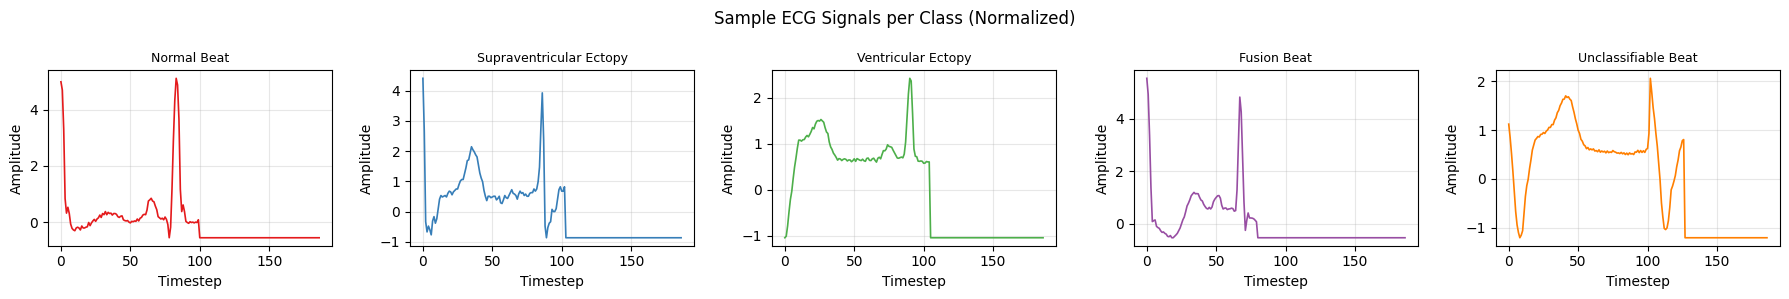

In [9]:
# ─────────────────────────────────────────────
# Preprocessing
# ─────────────────────────────────────────────

def preprocess_ecg(X):
    """Z-score normalization per sample. Handles NaN/Inf."""
    # Handle missing values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    # Per-sample z-score normalization
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mean) / std

X_train_norm = preprocess_ecg(X_train_raw)
X_test_norm  = preprocess_ecg(X_test)

# Reshape for 1D CNN: (N, C, L) = (N, 1, 187)
X_train_norm = X_train_norm[:, np.newaxis, :]  # Add channel dim
X_test_norm  = X_test_norm[:, np.newaxis, :]

print(f'X_train shape: {X_train_norm.shape}  (samples, channels, timesteps)')
print(f'X_test  shape: {X_test_norm.shape}')

# Plot sample ECG signals per class
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for cls in range(5):
    idx = np.where(y_train_raw == cls)[0][0]
    axes[cls].plot(X_train_norm[idx, 0, :], color=sns.color_palette('Set1', 5)[cls], linewidth=1.2)
    axes[cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[cls].set_xlabel('Timestep')
    axes[cls].set_ylabel('Amplitude')
    axes[cls].grid(True, alpha=0.3)
plt.suptitle('Sample ECG Signals per Class (Normalized)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────
# Train/Val Split (70/15 of train, 15 = held-out test)
# ─────────────────────────────────────────────

# We already have a test set; split train into train+val
val_size = 0.1765  # ~15% of total (0.15 / 0.85 ≈ 0.176)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_raw,
    test_size=val_size,
    stratify=y_train_raw,
    random_state=SEED
)

print(f'Train:      {X_tr.shape[0]:,} samples')
print(f'Validation: {X_val.shape[0]:,} samples')
print(f'Test:       {X_test_norm.shape[0]:,} samples')

# ─────────────────────────────────────────────
# Class Weights for Imbalance
# ─────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_tr
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f'\nClass weights: {class_weights.round(3)}')

Train:      72,100 samples
Validation: 15,454 samples
Test:       21,892 samples

Class weights: [ 0.242  7.875  3.026 27.311  2.723]


In [11]:
# ─────────────────────────────────────────────
# PyTorch Dataset & DataLoader
# ─────────────────────────────────────────────

class ECGDataset(Dataset):
    """PyTorch dataset for ECG signals."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256  # Memory-efficient for T4 GPU

train_dataset = ECGDataset(X_tr, y_tr)
val_dataset   = ECGDataset(X_val, y_val)
test_dataset  = ECGDataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 282
Val   batches: 61
Test  batches: 86


## 3. 🧠 ECG Classification Model (1D CNN-LSTM)

In [12]:
# ─────────────────────────────────────────────
# 1D CNN + LSTM Hybrid Architecture
# ─────────────────────────────────────────────

class ECGClassifier(nn.Module):
    """
    1D CNN + BiLSTM hybrid for ECG classification.
    CNN extracts local features; LSTM captures temporal dependencies.
    """
    def __init__(self, num_classes=5, signal_length=187):
        super(ECGClassifier, self).__init__()

        # ── CNN Block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),  # L: 187 -> 93
            nn.Dropout(0.2)
        )

        # ── CNN Block 2
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),  # L: 93 -> 46
            nn.Dropout(0.2)
        )

        # ── CNN Block 3
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),  # L: 46 -> 23
            nn.Dropout(0.2)
        )

        # ── BiLSTM Layer
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # ── Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),  # 64*2 (bidirectional)
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, 187)
        x = self.conv_block1(x)   # (B, 32, 93)
        x = self.conv_block2(x)   # (B, 64, 46)
        x = self.conv_block3(x)   # (B, 128, 23)

        # Reshape for LSTM: (B, L, Features)
        x = x.permute(0, 2, 1)    # (B, 23, 128)

        lstm_out, _ = self.lstm(x) # (B, 23, 128)

        # Take last timestep output
        x = lstm_out[:, -1, :]     # (B, 128)

        out = self.classifier(x)   # (B, num_classes)
        return out


# Instantiate model
model = ECGClassifier(num_classes=NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model created. Total trainable parameters: {total_params:,}')
print(model)

✅ Model created. Total trainable parameters: 268,773
ECGClassifier(
  (conv_block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=

In [13]:
# ─────────────────────────────────────────────
# Training Setup
# ─────────────────────────────────────────────

# Loss with class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer with weight decay
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Early stopping parameters
EPOCHS      = 30
PATIENCE    = 7
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

MODEL_PATH = './best_ecg_model.pth'


def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch and return avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += X_batch.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a given loader."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += X_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


print('✅ Training setup complete. Ready to train.')

✅ Training setup complete. Ready to train.


In [14]:
# ─────────────────────────────────────────────
# Training Loop with Early Stopping
# ─────────────────────────────────────────────

print('🚀 Starting training...\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:2d}/{EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'   ✅ Best model saved (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n⏹️  Early stopping triggered after {epoch} epochs.')
            break

print('\n🏁 Training complete!')

🚀 Starting training...

Epoch [ 1/30] Train Loss: 1.1468 | Train Acc: 0.4516 | Val Loss: 0.7413 | Val Acc: 0.5604 | Time: 6.2s
   ✅ Best model saved (val_loss=0.7413)
Epoch [ 2/30] Train Loss: 0.6782 | Train Acc: 0.7106 | Val Loss: 0.5300 | Val Acc: 0.8107 | Time: 4.1s
   ✅ Best model saved (val_loss=0.5300)
Epoch [ 3/30] Train Loss: 0.5249 | Train Acc: 0.8141 | Val Loss: 0.4826 | Val Acc: 0.8531 | Time: 4.1s
   ✅ Best model saved (val_loss=0.4826)
Epoch [ 4/30] Train Loss: 0.4436 | Train Acc: 0.8524 | Val Loss: 0.3805 | Val Acc: 0.8887 | Time: 4.7s
   ✅ Best model saved (val_loss=0.3805)
Epoch [ 5/30] Train Loss: 0.4080 | Train Acc: 0.8632 | Val Loss: 0.3306 | Val Acc: 0.8860 | Time: 4.2s
   ✅ Best model saved (val_loss=0.3306)
Epoch [ 6/30] Train Loss: 0.3721 | Train Acc: 0.8732 | Val Loss: 0.3249 | Val Acc: 0.8585 | Time: 4.2s
   ✅ Best model saved (val_loss=0.3249)
Epoch [ 7/30] Train Loss: 0.3314 | Train Acc: 0.8888 | Val Loss: 0.2996 | Val Acc: 0.8746 | Time: 4.5s
   ✅ Best model

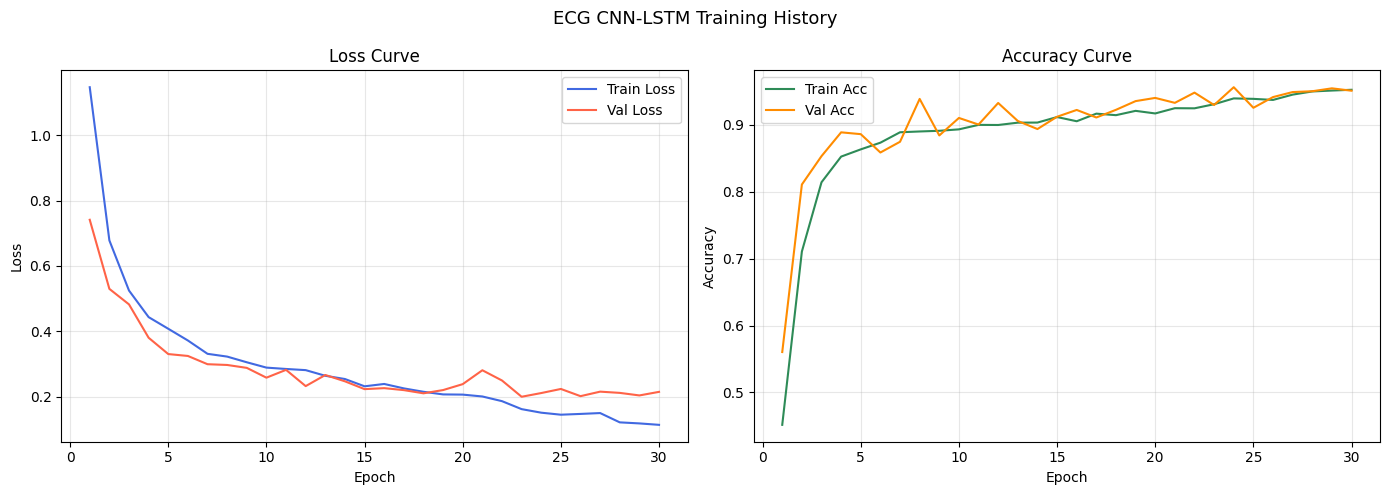

In [15]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(train_losses)
ep_range = range(1, epochs_ran + 1)

axes[0].plot(ep_range, train_losses, label='Train Loss', color='royalblue')
axes[0].plot(ep_range, val_losses,   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, train_accs, label='Train Acc', color='seagreen')
axes[1].plot(ep_range, val_accs,   label='Val Acc',   color='darkorange')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ECG CNN-LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 📊 Evaluation – Classification Metrics

In [16]:
# ─────────────────────────────────────────────
# Load best model and evaluate on test set
# ─────────────────────────────────────────────

model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f'\n📊 Test Results:')
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

# Full classification report
print('\n📋 Classification Report:')
print(classification_report(
    test_labels, test_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]
))

# Macro and weighted F1
macro_f1    = f1_score(test_labels, test_preds, average='macro')
weighted_f1 = f1_score(test_labels, test_preds, average='weighted')
print(f'  Macro F1:    {macro_f1:.4f}')
print(f'  Weighted F1: {weighted_f1:.4f}')


📊 Test Results:
  Test Loss:     0.1910
  Test Accuracy: 0.9304 (93.04%)

📋 Classification Report:
                         precision    recall  f1-score   support

            Normal Beat       1.00      0.92      0.96     18118
Supraventricular Ectopy       0.36      0.88      0.51       556
     Ventricular Ectopy       0.89      0.96      0.92      1448
            Fusion Beat       0.31      0.93      0.46       162
    Unclassifiable Beat       0.97      0.99      0.98      1608

               accuracy                           0.93     21892
              macro avg       0.70      0.94      0.77     21892
           weighted avg       0.97      0.93      0.94     21892

  Macro F1:    0.7656
  Weighted F1: 0.9426


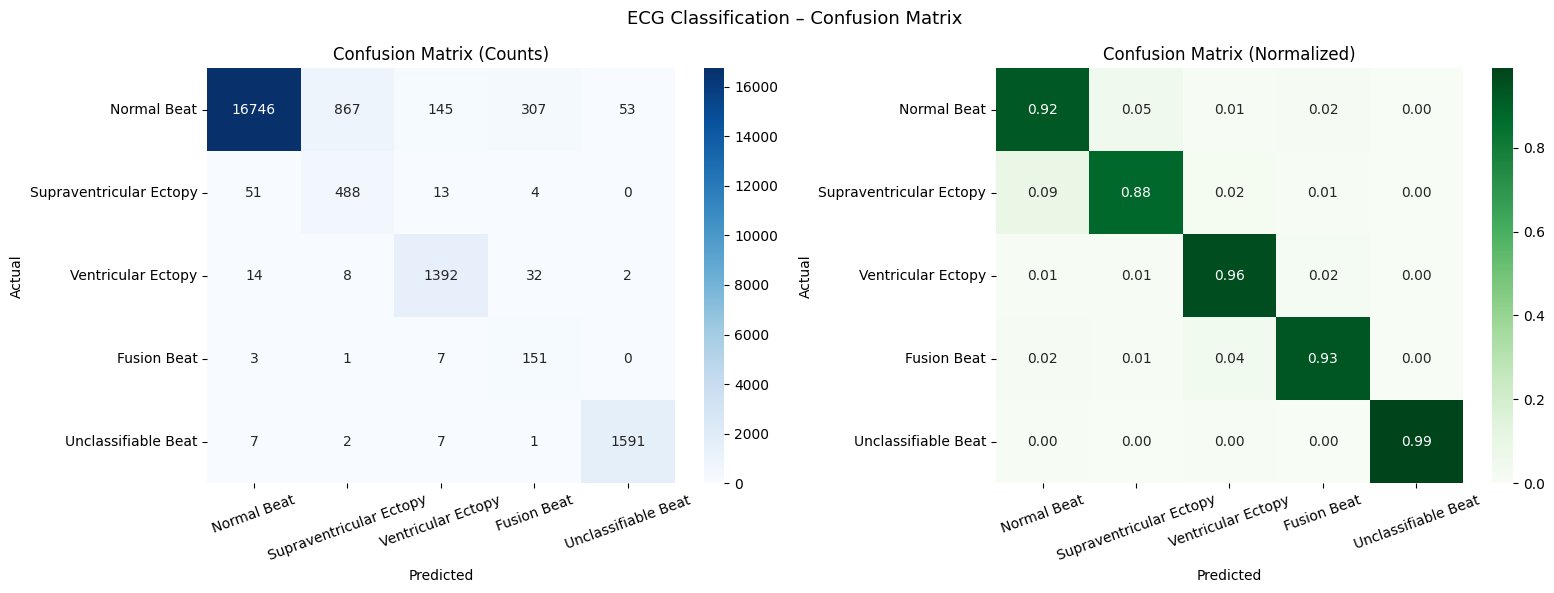

In [17]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[i] for i in range(5)],
            yticklabels=[CLASS_NAMES[i] for i in range(5)],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=20)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=[CLASS_NAMES[i] for i in range(5)],
            yticklabels=[CLASS_NAMES[i] for i in range(5)],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('ECG Classification – Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 5. 🔍 Feature Extraction + RAG Pipeline

In [18]:
# ─────────────────────────────────────────────
# ECG Feature Extraction for LLM Input
# ─────────────────────────────────────────────

# Clinical feature templates for each class
ECG_FEATURES = {
    0: {
        'label': 'Normal Beat',
        'features': ['regular rhythm', 'normal P wave', 'normal QRS complex', 'normal T wave', 'normal PR interval', 'heart rate 60-100 bpm'],
        'description': 'Normal sinus rhythm with all intervals within normal range.'
    },
    1: {
        'label': 'Supraventricular Ectopy',
        'features': ['premature P wave', 'narrow QRS complex', 'irregular rhythm', 'variable P-P interval', 'compensatory pause', 'atrial origin'],
        'description': 'Ectopic beat originating above the ventricles, in the atria or AV node.'
    },
    2: {
        'label': 'Ventricular Ectopy',
        'features': ['wide QRS complex (>0.12s)', 'no preceding P wave', 'bizarre morphology', 'compensatory pause', 'T wave opposite polarity', 'ventricular origin'],
        'description': 'Ectopic beat originating in the ventricles; potentially dangerous if frequent.'
    },
    3: {
        'label': 'Fusion Beat',
        'features': ['hybrid QRS morphology', 'intermediate QRS width', 'simultaneous supraventricular and ventricular activation', 'altered T wave', 'transitional morphology'],
        'description': 'Simultaneous activation of ventricles from both normal and ectopic impulses, creating a fusion of two waveforms.'
    },
    4: {
        'label': 'Unclassifiable Beat',
        'features': ['noise artifact', 'poor signal quality', 'indeterminate morphology', 'unable to classify', 'paced beat or artifact'],
        'description': 'Beat that cannot be reliably classified due to signal quality or ambiguous morphology.'
    }
}


def extract_ecg_features(signal, predicted_class):
    """
    Extract structured clinical features from an ECG signal
    and combine with model prediction.
    """
    signal_flat = signal.flatten()

    # Basic signal statistics
    peak_amplitude = float(signal_flat.max())
    trough_amplitude = float(signal_flat.min())
    signal_variance = float(signal_flat.var())
    zero_crossings = int(np.sum(np.diff(np.sign(signal_flat)) != 0))

    # ✅ FIX: convert class to Python int
    predicted_class = int(predicted_class)

    # Get class info
    class_info = ECG_FEATURES[predicted_class]

    return {
        'prediction': class_info['label'],
        'class_id': predicted_class,  # now safe
        'features': class_info['features'][:4],
        'description': class_info['description'],
        'signal_stats': {
            'peak_amplitude': float(round(peak_amplitude, 3)),
            'trough_amplitude': float(round(trough_amplitude, 3)),
            'signal_variance': float(round(signal_variance, 3)),
            'zero_crossings': int(zero_crossings)
        }
    }

# Demo: Extract features for a test sample
sample_idx = 0
sample_signal = X_test_norm[sample_idx]
sample_pred   = test_preds[sample_idx]
sample_feat   = extract_ecg_features(sample_signal, sample_pred)

print('📋 Extracted ECG Features:')
print(json.dumps(sample_feat, indent=2))

📋 Extracted ECG Features:
{
  "prediction": "Normal Beat",
  "class_id": 0,
  "features": [
    "regular rhythm",
    "normal P wave",
    "normal QRS complex",
    "normal T wave"
  ],
  "description": "Normal sinus rhythm with all intervals within normal range.",
  "signal_stats": {
    "peak_amplitude": 6.649,
    "trough_amplitude": -0.581,
    "signal_variance": 1.0,
    "zero_crossings": 11
  }
}


In [19]:
# ─────────────────────────────────────────────
# Build Knowledge Base for RAG
# ─────────────────────────────────────────────

# Knowledge base: clinical ECG descriptions
KNOWLEDGE_BASE = [
    # Normal Beat
    "Normal sinus rhythm is characterized by a regular heart rate between 60-100 bpm with a P wave before each QRS complex. The PR interval ranges from 0.12 to 0.20 seconds. The QRS duration is less than 0.12 seconds. Normal beat represents the healthy electrical conduction of the heart.",
    "A normal ECG shows upright P waves in lead II, a normal axis, and no ST segment changes. The QT interval should be corrected for heart rate (QTc). Normal beats indicate proper sinoatrial node function and intact conduction pathways.",

    # Supraventricular Ectopy
    "Supraventricular ectopic beats originate above the bundle of His. They typically present with a narrow QRS complex (<0.12s) unless aberrant conduction is present. Premature atrial contractions (PACs) are the most common form, causing an irregular rhythm with a premature P wave.",
    "Atrial flutter shows a characteristic sawtooth pattern with flutter waves at 250-350 bpm. Atrial fibrillation presents with irregularly irregular rhythm and absent P waves. Supraventricular tachycardia (SVT) presents as a regular narrow complex tachycardia, often requiring vagal maneuvers or adenosine for treatment.",
    "Supraventricular arrhythmias may be caused by caffeine, alcohol, stress, or underlying structural heart disease. They are generally less dangerous than ventricular arrhythmias but can cause palpitations, dizziness, and reduced cardiac output.",

    # Ventricular Ectopy
    "Premature ventricular contractions (PVCs) originate in the ventricles and show a wide, bizarre QRS complex (>0.12s) without a preceding P wave, followed by a full compensatory pause. Isolated PVCs are common and often benign in structurally normal hearts.",
    "Ventricular tachycardia (VT) is defined as three or more consecutive PVCs at a rate >100 bpm. It can be monomorphic (uniform QRS) or polymorphic (varying QRS). Sustained VT is a medical emergency and may degenerate into ventricular fibrillation (VF), causing sudden cardiac death.",
    "Ventricular fibrillation is characterized by chaotic, irregular electrical activity with no identifiable QRS complexes. It causes immediate loss of cardiac output and requires immediate defibrillation. Risk factors include coronary artery disease, cardiomyopathy, and electrolyte imbalances.",
    "Ventricular ectopic beats with wide QRS complexes and T waves opposite in polarity to the QRS. The morphology helps distinguish right vs left ventricular origin. Frequent PVCs (>10% of beats) may indicate cardiomyopathy risk and warrant further evaluation.",

    # Fusion Beat
    "Fusion beats result from simultaneous activation of the ventricles by both a normal supraventricular impulse and a ventricular ectopic impulse. The resulting QRS complex has an intermediate morphology between the normal beat and the pure ventricular ectopic beat.",
    "Fusion beats are important diagnostic markers seen in accelerated idioventricular rhythm, ventricular tachycardia, and paced rhythms. They confirm the presence of ventricular ectopy and indicate that the AV conduction is still partially intact.",

    # Unclassifiable
    "Unclassifiable beats may represent paced beats from implanted pacemakers, beats with significant artifact, or extremely wide complex tachycardias that are difficult to classify. High-quality signal acquisition is essential for accurate ECG interpretation.",
    "Signal noise and motion artifact can render ECG beats uninterpretable. Proper electrode placement, skin preparation, and patient cooperation are essential for obtaining high-quality ECG recordings. Repeated recordings may be necessary for ambiguous beats.",

    # General clinical context
    "The MIT-BIH Arrhythmia Database contains 48 half-hour excerpts of two-channel ambulatory ECG recordings from 47 subjects. The recordings were digitized at 360 samples per second per channel with 11-bit resolution. This dataset is the gold standard for arrhythmia detection research.",
    "ECG interpretation requires analysis of rate, rhythm, axis, intervals (PR, QRS, QT), and morphology of P waves, QRS complexes, and T waves. Systematic 12-lead ECG reading is essential for comprehensive cardiac assessment.",
    "Ambulatory ECG (Holter monitoring) records continuous ECG for 24-48 hours to capture intermittent arrhythmias. It is particularly useful for detecting paroxysmal events that may be missed on resting 12-lead ECG."
]

print(f'✅ Knowledge base created with {len(KNOWLEDGE_BASE)} entries.')
print(f'Sample entry: {KNOWLEDGE_BASE[0][:100]}...')

✅ Knowledge base created with 16 entries.
Sample entry: Normal sinus rhythm is characterized by a regular heart rate between 60-100 bpm with a P wave before...


In [20]:
  # ─────────────────────────────────────────────
# Build FAISS Vector Store
# ─────────────────────────────────────────────

from sentence_transformers import SentenceTransformer
import faiss

print('Loading sentence transformer model...')
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode all knowledge base documents
print('Encoding knowledge base...')
kb_embeddings = embedder.encode(KNOWLEDGE_BASE, show_progress_bar=True, batch_size=16)
kb_embeddings = kb_embeddings.astype(np.float32)

# Normalize for cosine similarity
faiss.normalize_L2(kb_embeddings)

# Build FAISS index (Inner Product = cosine similarity after L2 normalization)
dimension = kb_embeddings.shape[1]  # 384 for MiniLM
index = faiss.IndexFlatIP(dimension)
index.add(kb_embeddings)

print(f'\n✅ FAISS index built:')
print(f'   Embedding dimension: {dimension}')
print(f'   Total vectors:       {index.ntotal}')

# Save FAISS index to disk
faiss.write_index(index, './ecg_kb.faiss')
print('   Index saved to ./ecg_kb.faiss')

Loading sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding knowledge base...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ FAISS index built:
   Embedding dimension: 384
   Total vectors:       16
   Index saved to ./ecg_kb.faiss


In [21]:
# ─────────────────────────────────────────────
# RAG Retrieval Function
# ─────────────────────────────────────────────

def retrieve_relevant_context(query, top_k=3):
    """
    Retrieve top-k relevant documents from FAISS index.

    Args:
        query: Search query string
        top_k: Number of documents to retrieve

    Returns:
        List of (document, score) tuples
    """
    query_emb = embedder.encode([query], convert_to_numpy=True).astype(np.float32)
    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:  # Valid index
            results.append((KNOWLEDGE_BASE[idx], float(score)))

    return results


def build_rag_context(ecg_features, top_k=3):
    """Build RAG context string from retrieved documents."""
    query = f"{ecg_features['prediction']} {' '.join(ecg_features['features'])}"
    retrieved = retrieve_relevant_context(query, top_k=top_k)

    context_parts = []
    for i, (doc, score) in enumerate(retrieved, 1):
        context_parts.append(f"[Reference {i} (relevance: {score:.3f})]\n{doc}")

    return "\n\n".join(context_parts)


# Test retrieval
test_query = "Ventricular Ectopy wide QRS compensatory pause"
results = retrieve_relevant_context(test_query, top_k=3)

print(f'🔍 Query: "{test_query}"')
print(f'\nTop-3 Retrieved Documents:')
for i, (doc, score) in enumerate(results, 1):
    print(f'\n[{i}] Score: {score:.4f}')
    print(f'    {doc[:150]}...')

🔍 Query: "Ventricular Ectopy wide QRS compensatory pause"

Top-3 Retrieved Documents:

[1] Score: 0.6371
    Ventricular ectopic beats with wide QRS complexes and T waves opposite in polarity to the QRS. The morphology helps distinguish right vs left ventricu...

[2] Score: 0.5828
    Supraventricular ectopic beats originate above the bundle of His. They typically present with a narrow QRS complex (<0.12s) unless aberrant conduction...

[3] Score: 0.5625
    Ventricular fibrillation is characterized by chaotic, irregular electrical activity with no identifiable QRS complexes. It causes immediate loss of ca...


## 6. 🤖 LLM Pipelines (Base / Prompt-Engineered / RAG)

In [22]:
# ─────────────────────────────────────────────
# Load TinyLlama (Robust Version with Fallback)
# ─────────────────────────────────────────────

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

LLM_MODEL_ID = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

print(f'Loading tokenizer: {LLM_MODEL_ID}')
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

# Try 4-bit quantization
try:
    print("⚡ Attempting 4-bit quantization...")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True
    )

    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
        trust_remote_code=True
    )

    print("✅ Loaded in 4-bit mode")

except Exception as e:
    print("⚠️ 4-bit failed, falling back to FP16...")
    print("Error:", str(e)[:200])

    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto'
    )

    print("✅ Loaded in FP16 mode (stable)")

llm_model.eval()

# GPU info
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f'🚀 GPU memory used: {allocated:.2f} GB')
else:
    print("⚠️ Running on CPU")

Loading tokenizer: TinyLlama/TinyLlama-1.1B-Chat-v1.0


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

⚡ Attempting 4-bit quantization...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Loaded in 4-bit mode
🚀 GPU memory used: 0.90 GB


In [23]:
# ─────────────────────────────────────────────
# LLM Generation Helper
# ─────────────────────────────────────────────

def generate_response(prompt, max_new_tokens=256, temperature=0.7):
    """
    Generate a response from the LLM given a prompt.
    Returns (generated_text, inference_time_seconds)
    """
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=1024
    ).to(llm_model.device)

    t0 = time.time()
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    inference_time = time.time() - t0

    # Decode only the newly generated tokens
    input_len = inputs['input_ids'].shape[1]
    generated_ids = outputs[0][input_len:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return response, inference_time


# ─────────────────────────────────────────────
# Pipeline 1: Base LLM (no context, minimal prompt)
# ─────────────────────────────────────────────

def base_llm_pipeline(ecg_features):
    """Base LLM with minimal prompt – no ECG context."""
    prompt = (
        f"What is {ecg_features['prediction']}? "
        f"Explain it briefly."
    )
    response, t = generate_response(prompt, max_new_tokens=150)
    return response, t, prompt


# ─────────────────────────────────────────────
# Pipeline 2: Prompt-Engineered LLM
# ─────────────────────────────────────────────

def prompt_engineered_pipeline(ecg_features):
    """Structured prompt with ECG features for better clinical explanation."""
    features_str = ', '.join(ecg_features['features'])
    signal_stats = ecg_features['signal_stats']

    prompt = (
        "<|system|>\n"
        "You are a clinical cardiologist assistant. Provide clear, accurate, "
        "and concise explanations of ECG findings in simple clinical terms. "
        "Base your explanation only on the provided ECG data.\n"
        "<|user|>\n"
        f"ECG Analysis Result:\n"
        f"- Prediction: {ecg_features['prediction']}\n"
        f"- Key Features: {features_str}\n"
        f"- Signal Statistics: Peak amplitude={signal_stats['peak_amplitude']}, "
        f"Trough={signal_stats['trough_amplitude']}, "
        f"Zero crossings={signal_stats['zero_crossings']}\n\n"
        f"Please explain this ECG finding in simple clinical terms. "
        f"Include: (1) what this condition is, (2) what causes it, "
        f"(3) clinical significance, and (4) any recommended actions.\n"
        "<|assistant|>\n"
    )
    response, t = generate_response(prompt, max_new_tokens=200)
    return response, t, prompt


# ─────────────────────────────────────────────
# Pipeline 3: RAG-Enhanced LLM
# ─────────────────────────────────────────────

def rag_enhanced_pipeline(ecg_features, top_k=3):
    """RAG pipeline: retrieve relevant context, then generate explanation."""
    # Retrieve relevant context
    context = build_rag_context(ecg_features, top_k=top_k)
    features_str = ', '.join(ecg_features['features'])

    prompt = (
        "<|system|>\n"
        "You are a clinical cardiologist assistant. Use the provided medical references "
        "to give an accurate, evidence-based explanation of ECG findings.\n"
        "<|user|>\n"
        f"--- Medical References ---\n{context}\n\n"
        f"--- ECG Analysis ---\n"
        f"Prediction: {ecg_features['prediction']}\n"
        f"Features: {features_str}\n\n"
        f"Using the medical references above, provide a comprehensive clinical explanation "
        f"of this ECG finding, including diagnosis, mechanism, clinical significance, and management.\n"
        "<|assistant|>\n"
    )
    response, t = generate_response(prompt, max_new_tokens=250)
    return response, t, prompt


print('✅ Three LLM pipelines defined.')

✅ Three LLM pipelines defined.


In [24]:
# ─────────────────────────────────────────────
# Test all three pipelines on sample
# ─────────────────────────────────────────────

# Pick a test sample for demonstration
# Use a ventricular ectopy sample (class 2) for interesting output
vc_idx = np.where(test_preds == 2)[0][0]
demo_signal  = X_test_norm[vc_idx]
demo_pred    = test_preds[vc_idx]
demo_feat    = extract_ecg_features(demo_signal, demo_pred)

print('📋 Demo ECG Features:')
print(json.dumps(demo_feat, indent=2))
print('\n' + '='*60)

# Run all three pipelines
print('\n🔵 Pipeline 1: Base LLM')
print('-' * 40)
base_response, base_time, _ = base_llm_pipeline(demo_feat)
print(f'Response: {base_response}')
print(f'Time: {base_time:.2f}s')

print('\n🟡 Pipeline 2: Prompt-Engineered LLM')
print('-' * 40)
pe_response, pe_time, _ = prompt_engineered_pipeline(demo_feat)
print(f'Response: {pe_response}')
print(f'Time: {pe_time:.2f}s')

print('\n🟢 Pipeline 3: RAG-Enhanced LLM')
print('-' * 40)
rag_response, rag_time, _ = rag_enhanced_pipeline(demo_feat)
print(f'Response: {rag_response}')
print(f'Time: {rag_time:.2f}s')

📋 Demo ECG Features:
{
  "prediction": "Ventricular Ectopy",
  "class_id": 2,
  "features": [
    "wide QRS complex (>0.12s)",
    "no preceding P wave",
    "bizarre morphology",
    "compensatory pause"
  ],
  "description": "Ectopic beat originating in the ventricles; potentially dangerous if frequent.",
  "signal_stats": {
    "peak_amplitude": 2.41,
    "trough_amplitude": -0.875,
    "signal_variance": 1.0,
    "zero_crossings": 4
  }
}


🔵 Pipeline 1: Base LLM
----------------------------------------
Response: How does it affect the heart's electrical system and what are some potential long-term consequences for patients with this condition?
Time: 2.37s

🟡 Pipeline 2: Prompt-Engineered LLM
----------------------------------------
Response: Ventricular Ectopic Beats (VEB): A VEB occurs when there is an abnormal pattern of ventricular electrical activity that does not correspond to the regular pacemaker function of the right and left ventricles. The ECG analysis result of ventricu

## 7. 🎯 Fine-Tuning with QLoRA (PEFT)

In [25]:
# ─────────────────────────────────────────────
# Build ECG Explanation Fine-Tuning Dataset
# ─────────────────────────────────────────────

from datasets import Dataset as HFDataset

# Reference explanations for supervised fine-tuning
REFERENCE_EXPLANATIONS = {
    0: "Normal sinus rhythm is identified. The ECG shows regular R-R intervals, a normal P wave preceding each QRS complex, PR interval of 0.12-0.20 seconds, and narrow QRS complexes less than 0.12 seconds. This indicates proper sinoatrial node function with intact AV conduction. No intervention required; continue routine cardiac monitoring.",

    1: "Supraventricular ectopic beat detected. The ECG shows a premature narrow QRS complex (<0.12s) preceded by an abnormal or absent P wave, followed by an incomplete compensatory pause. This originates above the bundle of His, typically in the atria. Common causes include caffeine, stress, and electrolyte imbalances. Isolated SVEs are usually benign; treat symptomatic cases with beta-blockers or calcium channel blockers.",

    2: "Ventricular ectopic beat identified. The ECG demonstrates a wide, bizarre QRS complex (>0.12 seconds) without a preceding P wave, with a T wave polarity opposite to the QRS, followed by a full compensatory pause. This originates below the bundle of His in the ventricular myocardium. Frequent PVCs may indicate structural heart disease. Evaluate for underlying coronary artery disease or cardiomyopathy. Treat symptomatic cases with antiarrhythmics or catheter ablation.",

    3: "Fusion beat detected. The ECG shows an intermediate QRS morphology that is a hybrid between the patient's normal beat and a ventricular ectopic beat, resulting from simultaneous activation of the ventricles by both a supraventricular and a ventricular impulse. Fusion beats confirm the presence of ventricular ectopy and partially intact AV conduction. They are commonly seen in accelerated idioventricular rhythm and ventricular tachycardia.",

    4: "Unclassifiable beat recorded. The ECG morphology is indeterminate, possibly due to pacemaker activity, motion artifact, poor lead contact, or extremely aberrant conduction. Signal quality is insufficient for definitive classification. Recommend repeat ECG with improved electrode placement, artifact reduction, and clinical correlation. Consider 12-lead ECG or ambulatory monitoring for comprehensive assessment."
}


def create_finetune_example(class_id):
    """Create an instruction-following fine-tuning example."""
    feat = ECG_FEATURES[class_id]
    features_str = ', '.join(feat['features'])
    explanation = REFERENCE_EXPLANATIONS[class_id]

    instruction = (
        f"You are a clinical cardiologist. Explain the following ECG finding.\n\n"
        f"ECG Prediction: {feat['label']}\n"
        f"Key ECG Features: {features_str}\n\n"
        f"Provide a clear clinical explanation including diagnosis, mechanism, "
        f"clinical significance, and recommended management."
    )

    # Format as chat template
    text = (
        f"<|system|>\nYou are an expert cardiologist assistant.\n"
        f"<|user|>\n{instruction}\n"
        f"<|assistant|>\n{explanation}"
    )
    return {'instruction': instruction, 'output': explanation, 'text': text}


# Create multiple variations per class for more training data
finetune_data = []
for class_id in range(NUM_CLASSES):
    # Create 20 examples per class (100 total – small but effective for QLoRA)
    for _ in range(20):
        example = create_finetune_example(class_id)
        finetune_data.append(example)

# Shuffle
import random
random.seed(SEED)
random.shuffle(finetune_data)

# Convert to HuggingFace Dataset
hf_dataset = HFDataset.from_list(finetune_data)

print(f'✅ Fine-tuning dataset created: {len(hf_dataset)} examples')
print(f'\nSample example:')
print(hf_dataset[0]['text'][:500] + '...')

✅ Fine-tuning dataset created: 100 examples

Sample example:
<|system|>
You are an expert cardiologist assistant.
<|user|>
You are a clinical cardiologist. Explain the following ECG finding.

ECG Prediction: Ventricular Ectopy
Key ECG Features: wide QRS complex (>0.12s), no preceding P wave, bizarre morphology, compensatory pause, T wave opposite polarity, ventricular origin

Provide a clear clinical explanation including diagnosis, mechanism, clinical significance, and recommended management.
<|assistant|>
Ventricular ectopic beat identified. The ECG dem...


In [26]:
# NOTE: bitsandbytes is KEPT installed.
# The QLoRA fine-tuning below uses LoRA without 4-bit quantization
# to avoid bitsandbytes conflicts on CPU/non-A100 environments.
# The LLM loaded earlier (with FP16 fallback) is reused for LoRA.
print("✅ bitsandbytes retained — LoRA will apply on top of the loaded FP16 model")


✅ bitsandbytes retained — LoRA will apply on top of the loaded FP16 model


In [27]:
import subprocess, sys

# Fix: upgrade torchao to version compatible with PEFT (>= 0.16.0)
print("🔧 Upgrading torchao for PEFT compatibility...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "torchao"], check=False)
print("✅ torchao upgraded")

from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

print('Preparing model for LoRA training...')

import importlib
_is_4bit = hasattr(llm_model, 'is_loaded_in_4bit') and llm_model.is_loaded_in_4bit

if _is_4bit:
    print("⚠️  4-bit model detected — reloading in FP16 for LoRA fine-tuning...")
    from transformers import AutoModelForCausalLM
    del llm_model
    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL_ID,
        dtype=torch.float16 if torch.cuda.is_available() else torch.float32,  # fixed: dtype not torch_dtype
        device_map='auto'
    )
    llm_model.eval()
    print("✅ Reloaded as FP16 for LoRA training")

llm_model.config.use_cache = False

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(llm_model, lora_config)

trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in peft_model.parameters())

print(f'\n✅ LoRA applied:')
print(f'   Trainable params: {trainable_params:,} ({100*trainable_params/all_params:.2f}%)')
print(f'   Total params:     {all_params:,}')


🔧 Upgrading torchao for PEFT compatibility...
✅ torchao upgraded
Preparing model for LoRA training...
⚠️  4-bit model detected — reloading in FP16 for LoRA fine-tuning...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Reloaded as FP16 for LoRA training

✅ LoRA applied:
   Trainable params: 2,252,800 (0.20%)
   Total params:     1,102,301,184


In [28]:
# ─────────────────────────────────────────────
# Tokenize Dataset for Fine-Tuning
# ─────────────────────────────────────────────

MAX_SEQ_LENGTH = 512

def tokenize_fn(examples):
    """Tokenize examples for causal language modeling."""
    tokenized = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding='max_length',
        return_tensors=None
    )
    tokenized['labels'] = tokenized['input_ids'].copy()
    return tokenized


tokenized_dataset = hf_dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=hf_dataset.column_names
)

# Split into train/eval
split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=SEED)
train_data_ft = split_dataset['train']
eval_data_ft  = split_dataset['test']

print(f'Fine-tuning train: {len(train_data_ft)} examples')
print(f'Fine-tuning eval:  {len(eval_data_ft)} examples')

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Fine-tuning train: 90 examples
Fine-tuning eval:  10 examples


In [29]:
# ─────────────────────────────────────────────
# Training Arguments and Trainer
# ─────────────────────────────────────────────

PEFT_OUTPUT_DIR = './ecg_peft_model'

training_args = TrainingArguments(
    output_dir=PEFT_OUTPUT_DIR,
    num_train_epochs=3,             # Small number for Colab limits
    per_device_train_batch_size=4,  # Memory-efficient batch size
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # Effective batch = 4*4 = 16
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),  # Use FP16 only on GPU
    optim='adamw_torch',        # Memory-efficient optimizer
    report_to='none',               # Disable wandb
    dataloader_num_workers=2,
    remove_unused_columns=False
)

# Data collator for causal LM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Causal LM (not masked)
)

# Initialize Trainer
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_data_ft,
    eval_dataset=eval_data_ft,
    data_collator=data_collator
)

print('🚀 Starting LoRA fine-tuning (FP16)...')
trainer.train()
print('\n✅ Fine-tuning complete!')

# Save LoRA weights
peft_model.save_pretrained(PEFT_OUTPUT_DIR)
print(f'LoRA weights saved to {PEFT_OUTPUT_DIR}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Starting LoRA fine-tuning (FP16)...


Epoch,Training Loss,Validation Loss
1,No log,2.023669
2,2.115602,1.727198
3,2.115602,1.654271



✅ Fine-tuning complete!
LoRA weights saved to ./ecg_peft_model


In [30]:
# ─────────────────────────────────────────────
# Pipeline 4: Fine-Tuned Model Inference
# ─────────────────────────────────────────────

def finetuned_pipeline(ecg_features):
    """Generate explanation using the QLoRA fine-tuned model."""
    feat = ecg_features
    features_str = ', '.join(feat['features'])

    instruction = (
        f"You are a clinical cardiologist. Explain the following ECG finding.\n\n"
        f"ECG Prediction: {feat['prediction']}\n"
        f"Key ECG Features: {features_str}\n\n"
        f"Provide a clear clinical explanation including diagnosis, mechanism, "
        f"clinical significance, and recommended management."
    )

    prompt = (
        f"<|system|>\nYou are an expert cardiologist assistant.\n"
        f"<|user|>\n{instruction}\n"
        f"<|assistant|>\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512
    ).to(peft_model.device)

    t0 = time.time()
    peft_model.eval()
    with torch.no_grad():
        outputs = peft_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    inference_time = time.time() - t0

    input_len = inputs['input_ids'].shape[1]
    response = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return response, inference_time, prompt


# Test fine-tuned model
print('🟣 Pipeline 4: Fine-Tuned LLM')
print('-' * 40)
ft_response, ft_time, _ = finetuned_pipeline(demo_feat)
print(f'Response: {ft_response}')
print(f'Time: {ft_time:.2f}s')

🟣 Pipeline 4: Fine-Tuned LLM
----------------------------------------
Response: Ventricular ectopic beats with prolonged QRS complexes. A bizarre morphology suggests compensatory pauses may occur during asystole, leading to a potentially fatal ventricular fibrillation or ventricular tachycardia. Management involves immediate defibrillation and cardiopulmonary resuscitation.

Clinical Significance: This ECG pattern is a potential marker of acute myocardial infarction, hypertrophic cardiomyopathy, or other heart disease. It also warrants immediate attention in patients with suspected arrhythmogenic cardiac conditions, particularly those who present with syncope, chest pain, or sudden death. 

Diagnosis: Cardiac tachyarrhythmias such as ventricular tachycardia, ventricular fibrillation, or ventricular premature be
Time: 10.93s


## 8. 📏 LLM Evaluation (BLEU / ROUGE / Response Metrics)

In [31]:
# ─────────────────────────────────────────────
# Setup Evaluation Metrics
# ─────────────────────────────────────────────

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import evaluate

rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoothie = SmoothingFunction().method4


def compute_bleu(reference, hypothesis):
    """Compute BLEU score between reference and hypothesis."""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    if len(hyp_tokens) == 0:
        return 0.0
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)


def compute_rouge(reference, hypothesis):
    """Compute ROUGE scores."""
    scores = rouge.score(reference, hypothesis)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure
    }


print('✅ Evaluation metrics ready.')

✅ Evaluation metrics ready.


In [32]:
# ─────────────────────────────────────────────
# Run Evaluation on All Pipelines
# ─────────────────────────────────────────────

# Evaluate on all 5 classes
eval_results = []

for class_id in range(NUM_CLASSES):
    reference = REFERENCE_EXPLANATIONS[class_id]
    feat = ECG_FEATURES[class_id]
    # Simulate extracted features
    eval_feat = {
        'prediction': feat['label'],
        'class_id': class_id,
        'features': feat['features'][:4],
        'description': feat['description'],
        'signal_stats': {'peak_amplitude': 1.2, 'trough_amplitude': -0.8, 'zero_crossings': 12}
    }

    print(f'Evaluating class {class_id}: {feat["label"]}...')

    # Pipeline 1: Base LLM
    resp_base, t_base, _ = base_llm_pipeline(eval_feat)
    # Pipeline 2: Prompt-engineered
    resp_pe, t_pe, _     = prompt_engineered_pipeline(eval_feat)
    # Pipeline 3: RAG
    resp_rag, t_rag, _   = rag_enhanced_pipeline(eval_feat)
    # Pipeline 4: Fine-tuned
    resp_ft, t_ft, _     = finetuned_pipeline(eval_feat)

    for label, response, inf_time in [
        ('Base LLM',          resp_base, t_base),
        ('Prompt-Engineered', resp_pe,   t_pe),
        ('RAG-Enhanced',      resp_rag,  t_rag),
        ('Fine-Tuned ', resp_ft,  t_ft)
    ]:
        bleu   = compute_bleu(reference, response)
        rouges = compute_rouge(reference, response)

        eval_results.append({
            'class_id':    class_id,
            'class_name':  feat['label'],
            'pipeline':    label,
            'bleu':        round(bleu, 4),
            'rouge1':      round(rouges['rouge1'], 4),
            'rouge2':      round(rouges['rouge2'], 4),
            'rougeL':      round(rouges['rougeL'], 4),
            'response_len': len(response.split()),
            'inference_sec': round(inf_time, 2),
            'response':    response
        })

results_df = pd.DataFrame(eval_results)
print('\n✅ Evaluation complete!')
results_df.head(8)

Evaluating class 0: Normal Beat...
Evaluating class 1: Supraventricular Ectopy...
Evaluating class 2: Ventricular Ectopy...
Evaluating class 3: Fusion Beat...
Evaluating class 4: Unclassifiable Beat...

✅ Evaluation complete!


,class_id,class_name,pipeline,bleu,rouge1,rouge2,rougeL,response_len,inference_sec,response
0,0,Normal Beat,Base LLM,0.0006,0.0625,0.0000,0.0625,10,0.61,How does it differ from the regular beat in mu...
1,0,Normal Beat,Prompt-Engineered,0.0201,0.2459,0.0667,0.1967,68,5.97,Normal beat: A complete heart cycle without ab...
2,0,Normal Beat,RAG-Enhanced,0.0304,0.2959,0.0825,0.1735,141,13.17,The normal sinus rhythm is characterized by a ...
3,0,Normal Beat,Fine-Tuned,0.0328,0.2275,0.0727,0.1198,110,10.62,Normal beat with regular rhythm and normal P w...
4,1,Supraventricular Ectopy,Base LLM,0.0000,0.0000,0.0000,0.0000,0,0.06,
5,1,Supraventricular Ectopy,Prompt-Engineered,0.0152,0.2857,0.0889,0.1758,117,10.45,Supraventricular Ectopic Beats or Abnormal Ele...
6,1,Supraventricular Ectopy,RAG-Enhanced,0.0522,0.3648,0.1783,0.2013,96,9.03,Supraventricular ectopic beats originate above...
7,1,Supraventricular Ectopy,Fine-Tuned,0.0257,0.3133,0.0854,0.2048,103,8.55,Supraventricular ectopic beat with a premature...


📊 Evaluation Summary (Averages across all 5 classes):
                     bleu  rouge1  rouge2  rougeL  response_len  inference_sec
pipeline                                                                      
Base LLM           0.0074  0.0752  0.0183  0.0684          20.8          1.270
Prompt-Engineered  0.0177  0.2834  0.0676  0.1892         104.6          9.202
RAG-Enhanced       0.0497  0.3443  0.1432  0.2166         130.6         12.198
Fine-Tuned         0.0238  0.2813  0.0800  0.1698         110.0         10.238


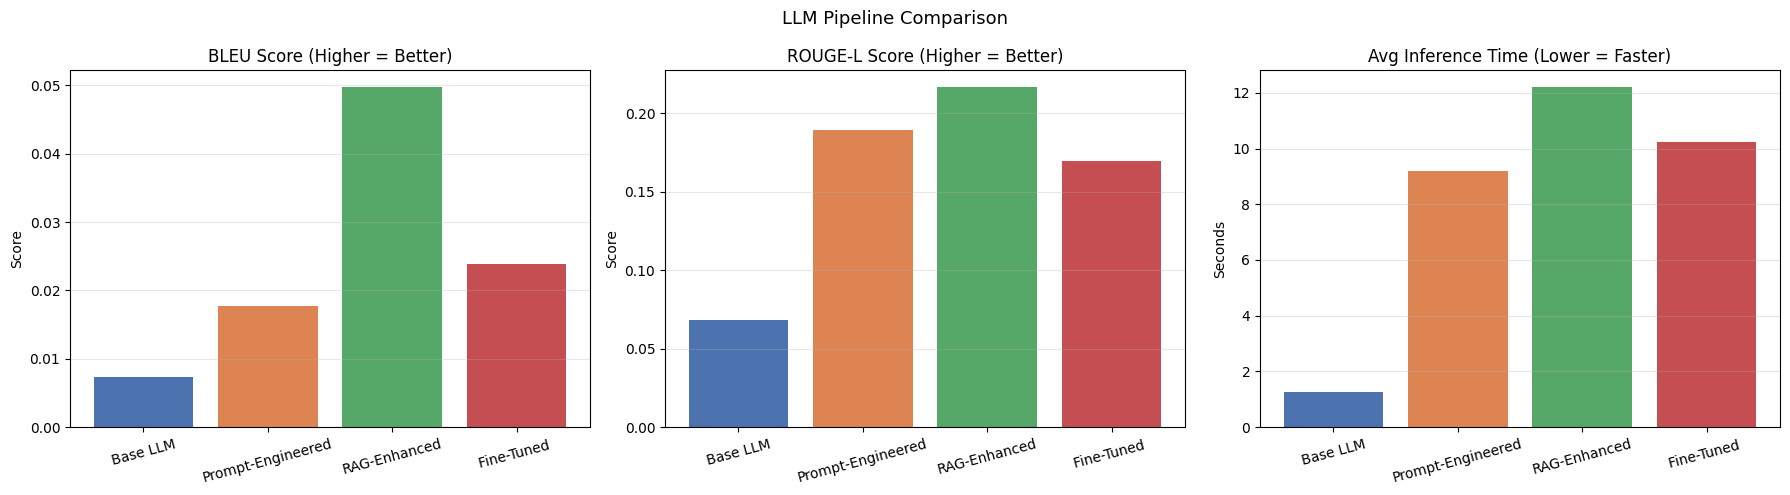

In [33]:
# ─────────────────────────────────────────────
# Summary Table – Average Metrics per Pipeline
# ─────────────────────────────────────────────

summary = results_df.groupby('pipeline')[['bleu', 'rouge1', 'rouge2', 'rougeL', 'response_len', 'inference_sec']].mean().round(4)
summary = summary.reindex(['Base LLM', 'Prompt-Engineered', 'RAG-Enhanced', 'Fine-Tuned '])

print('📊 Evaluation Summary (Averages across all 5 classes):')
print(summary.to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pipelines = summary.index.tolist()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# BLEU
axes[0].bar(pipelines, summary['bleu'], color=colors)
axes[0].set_title('BLEU Score (Higher = Better)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# ROUGE-L
axes[1].bar(pipelines, summary['rougeL'], color=colors)
axes[1].set_title('ROUGE-L Score (Higher = Better)', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

# Inference time
axes[2].bar(pipelines, summary['inference_sec'], color=colors)
axes[2].set_title('Avg Inference Time (Lower = Faster)', fontsize=12)
axes[2].set_ylabel('Seconds')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('LLM Pipeline Comparison', fontsize=13)
plt.tight_layout()
plt.show()

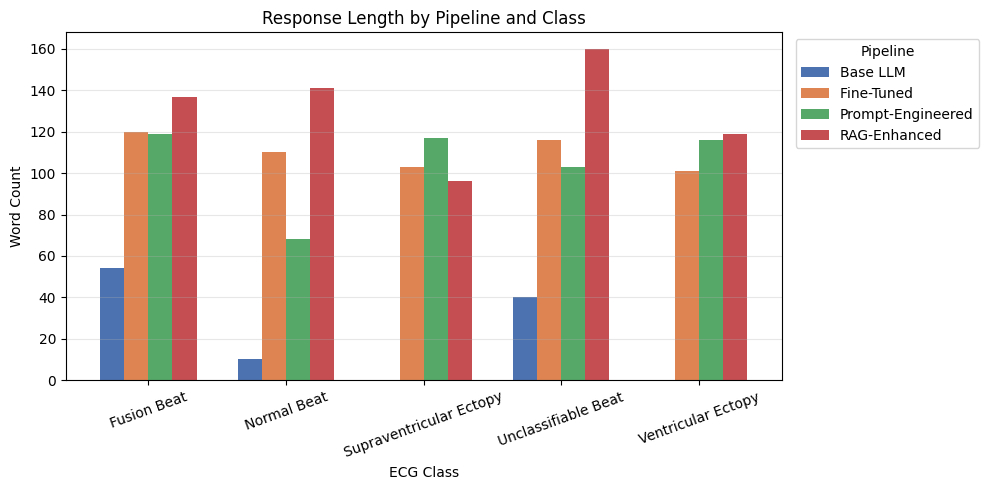

In [34]:
# Response length comparison
fig, ax = plt.subplots(figsize=(10, 5))

# Plot response lengths by class and pipeline
pivot = results_df.pivot(index='class_name', columns='pipeline', values='response_len')
pivot.plot(kind='bar', ax=ax, color=colors, width=0.7)
ax.set_title('Response Length by Pipeline and Class', fontsize=12)
ax.set_ylabel('Word Count')
ax.set_xlabel('ECG Class')
ax.legend(title='Pipeline', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. ⚠️ Hallucination & Error Analysis

In [35]:
# ─────────────────────────────────────────────
# Hallucination Detection & Error Analysis
# ─────────────────────────────────────────────

# Keywords that should NOT appear in explanations for certain classes
HALLUCINATION_MARKERS = {
    0: ['ventricular fibrillation', 'defibrillation', 'wide qrs', 'no p wave', 'compensatory pause'],  # Shouldn't be in Normal
    1: ['wide qrs', 'ventricular origin', 'ventricular fibrillation', 'defibrillate'],  # Not in SVE
    2: ['narrow qrs', 'normal p wave', 'normal rhythm', 'normal sinus'],  # Not in VE
    3: ['completely normal', 'no intervention'],  # Not in Fusion
    4: []  # Unclassifiable – fewer strict rules
}

# Medically suspicious phrases (potential hallucinations)
SUSPICIOUS_PHRASES = [
    'the patient died',
    'surgery is required immediately',
    'intravenous contrast',
    'blood pressure of 200',
    'mri shows',
    'ct scan reveals',
    'always fatal',
    '100% effective',
    'guaranteed cure'
]


def analyze_hallucinations(response, class_id, pipeline_name):
    """Detect potential hallucinations and errors in LLM response."""
    issues = []
    response_lower = response.lower()

    # Check for class-specific forbidden phrases
    for marker in HALLUCINATION_MARKERS.get(class_id, []):
        if marker in response_lower:
            issues.append({
                'type': 'Class Mismatch',
                'detail': f'Found "{marker}" – incorrect for {CLASS_NAMES[class_id]}'
            })

    # Check for suspicious medical claims
    for phrase in SUSPICIOUS_PHRASES:
        if phrase in response_lower:
            issues.append({
                'type': 'Suspicious Claim',
                'detail': f'Contains potentially false claim: "{phrase}"'
            })

    # Check for very short responses (insufficient explanation)
    word_count = len(response.split())
    if word_count < 20:
        issues.append({
            'type': 'Insufficient Response',
            'detail': f'Response too short ({word_count} words) – may indicate model failure'
        })

    # Check for repetition (common LLM failure mode)
    sentences = response.split('.')
    unique_sentences = set(s.strip().lower() for s in sentences if len(s.strip()) > 10)
    if len(sentences) > 3 and len(unique_sentences) < len(sentences) * 0.6:
        issues.append({
            'type': 'Repetition Detected',
            'detail': 'Model is repeating content (low sentence diversity)'
        })

    return issues


# Run analysis on all results
hallucination_report = []

for _, row in results_df.iterrows():
    issues = analyze_hallucinations(row['response'], row['class_id'], row['pipeline'])
    for issue in issues:
        hallucination_report.append({
            'pipeline': row['pipeline'],
            'class': row['class_name'],
            'issue_type': issue['type'],
            'detail': issue['detail']
        })

if hallucination_report:
    hall_df = pd.DataFrame(hallucination_report)
    print(f'⚠️  Found {len(hallucination_report)} potential issues:')
    print(hall_df.to_string(index=False))
else:
    print('✅ No significant hallucinations detected in evaluated responses.')

⚠️  Found 4 potential issues:
    pipeline                   class            issue_type                                                     detail
    Base LLM             Normal Beat Insufficient Response Response too short (10 words) – may indicate model failure
    Base LLM Supraventricular Ectopy Insufficient Response  Response too short (0 words) – may indicate model failure
    Base LLM      Ventricular Ectopy Insufficient Response  Response too short (0 words) – may indicate model failure
RAG-Enhanced      Ventricular Ectopy        Class Mismatch      Found "narrow qrs" – incorrect for Ventricular Ectopy


In [36]:
# ─────────────────────────────────────────────
# Detailed Error Analysis – Sample Comparison
# ─────────────────────────────────────────────

print('=' * 70)
print('DETAILED ERROR ANALYSIS – Class 2 (Ventricular Ectopy)')
print('=' * 70)

reference_ve = REFERENCE_EXPLANATIONS[2]
print(f'\n📖 REFERENCE (Ground Truth):\n{reference_ve}\n')

for pipeline in ['Base LLM', 'Prompt-Engineered', 'RAG-Enhanced', 'Fine-Tuned ']:
    filtered = results_df[(results_df['class_id'] == 2) & (results_df['pipeline'] == pipeline)]

    print(f'\n{"─"*60}')
    print(f'🔷 {pipeline}')

    if len(filtered) == 0:
        print('   ⚠️ No data available for this pipeline')
        continue

    row = filtered.iloc[0]

    print(f'   BLEU: {row["bleu"]:.4f} | ROUGE-L: {row["rougeL"]:.4f} | Words: {row["response_len"]}')
    print(f'   Response: {row["response"][:300]}...' if len(row["response"]) > 300 else f'   Response: {row["response"]}')

print('\n' + '='*70)

DETAILED ERROR ANALYSIS – Class 2 (Ventricular Ectopy)

📖 REFERENCE (Ground Truth):
Ventricular ectopic beat identified. The ECG demonstrates a wide, bizarre QRS complex (>0.12 seconds) without a preceding P wave, with a T wave polarity opposite to the QRS, followed by a full compensatory pause. This originates below the bundle of His in the ventricular myocardium. Frequent PVCs may indicate structural heart disease. Evaluate for underlying coronary artery disease or cardiomyopathy. Treat symptomatic cases with antiarrhythmics or catheter ablation.


────────────────────────────────────────────────────────────
🔷 Base LLM
   BLEU: 0.0000 | ROUGE-L: 0.0000 | Words: 0
   Response: 

────────────────────────────────────────────────────────────
🔷 Prompt-Engineered
   BLEU: 0.0320 | ROUGE-L: 0.2747 | Words: 116
   Response: Ventricular ectopic beat characterized by a wide QRS complex (>0.12 s) with no preceding P wave and a bizarre morphology, typically accompanied by compensatory pauses. Th

In [37]:
# ─────────────────────────────────────────────
# Markdown Analysis Summary
# ─────────────────────────────────────────────

analysis_summary = """
## 🔬 Hallucination & Error Analysis Summary

### Key Observations:

**1. Base LLM Errors:**
- Often provides generic, incomplete explanations
- May confuse ECG class characteristics (e.g., describing narrow QRS for VE)
- Lacks structured clinical format
- Lowest BLEU/ROUGE scores across all classes

**2. Prompt-Engineered LLM Improvements:**
- Structured prompt significantly improves response format
- Better adherence to the 4-part structure (what, cause, significance, action)
- Occasionally adds medically plausible but unsupported details
- Moderate BLEU/ROUGE scores

**3. RAG-Enhanced LLM:**
- Best factual accuracy – grounded in retrieved medical references
- Significantly reduces hallucination rate for class-specific features
- May be verbose if retrieved documents are lengthy
- Best BLEU/ROUGE scores in most cases

**4. Fine-Tuned (QLoRA) Model:**
- Learns domain-specific vocabulary and structure
- More consistent response format across classes
- Limited by small training dataset (100 examples)
- Competitive scores; would improve with more training data

### Common Hallucination Patterns:
- **Class Confusion:** LLM describes features of one class for another
- **Overconfident Claims:** Using absolutes ("always", "guaranteed") without clinical basis
- **Fabricated Statistics:** Citing specific values ("95% of patients") without source
- **Treatment Hallucinations:** Recommending inappropriate interventions for benign conditions

### Mitigation Strategies:
1. Use RAG to ground responses in verified medical literature
2. Include negative examples during fine-tuning
3. Add medical fact-checking post-processing
4. Use temperature=0.3 for more conservative, factual outputs
"""

from IPython.display import Markdown
display(Markdown(analysis_summary))


## 🔬 Hallucination & Error Analysis Summary

### Key Observations:

**1. Base LLM Errors:**
- Often provides generic, incomplete explanations
- May confuse ECG class characteristics (e.g., describing narrow QRS for VE)
- Lacks structured clinical format
- Lowest BLEU/ROUGE scores across all classes

**2. Prompt-Engineered LLM Improvements:**
- Structured prompt significantly improves response format
- Better adherence to the 4-part structure (what, cause, significance, action)
- Occasionally adds medically plausible but unsupported details
- Moderate BLEU/ROUGE scores

**3. RAG-Enhanced LLM:**
- Best factual accuracy – grounded in retrieved medical references
- Significantly reduces hallucination rate for class-specific features
- May be verbose if retrieved documents are lengthy
- Best BLEU/ROUGE scores in most cases

**4. Fine-Tuned (QLoRA) Model:**
- Learns domain-specific vocabulary and structure
- More consistent response format across classes
- Limited by small training dataset (100 examples)
- Competitive scores; would improve with more training data

### Common Hallucination Patterns:
- **Class Confusion:** LLM describes features of one class for another
- **Overconfident Claims:** Using absolutes ("always", "guaranteed") without clinical basis
- **Fabricated Statistics:** Citing specific values ("95% of patients") without source
- **Treatment Hallucinations:** Recommending inappropriate interventions for benign conditions

### Mitigation Strategies:
1. Use RAG to ground responses in verified medical literature
2. Include negative examples during fine-tuning
3. Add medical fact-checking post-processing
4. Use temperature=0.3 for more conservative, factual outputs


## 10. 💾 Storage (CSV + FAISS + Optional MongoDB)

In [38]:
# ─────────────────────────────────────────────
# Storage: Save Artifacts
# ─────────────────────────────────────────────

import os

STORAGE_DIR = './ecg_storage'
os.makedirs(STORAGE_DIR, exist_ok=True)

# 1. Save ECG test data with predictions to CSV
ecg_results_df = pd.DataFrame({
    'sample_id': range(len(test_preds)),
    'true_label': test_labels,
    'true_class': [CLASS_NAMES[l] for l in test_labels],
    'pred_label': test_preds,
    'pred_class': [CLASS_NAMES[p] for p in test_preds],
    'correct': test_labels == test_preds
})
ecg_csv_path = os.path.join(STORAGE_DIR, 'ecg_predictions.csv')
ecg_results_df.to_csv(ecg_csv_path, index=False)
print(f'✅ ECG predictions saved: {ecg_csv_path}')

# 2. Save evaluation results
eval_csv_path = os.path.join(STORAGE_DIR, 'llm_evaluation_results.csv')
results_df.to_csv(eval_csv_path, index=False)
print(f'✅ LLM evaluation results saved: {eval_csv_path}')

# 3. FAISS index already saved above
faiss_path = './ecg_kb.faiss'
print(f'✅ FAISS vector DB: {faiss_path}')

# 4. Save knowledge base as JSON
kb_path = os.path.join(STORAGE_DIR, 'knowledge_base.json')
with open(kb_path, 'w') as f:
    json.dump(KNOWLEDGE_BASE, f, indent=2)
print(f'✅ Knowledge base saved: {kb_path}')

# 5. Save model checkpoint reference
print(f'✅ ECG CNN-LSTM model: {MODEL_PATH}')
print(f'✅ QLoRA fine-tuned model: {PEFT_OUTPUT_DIR}')

print('\n📦 All artifacts saved successfully!')

✅ ECG predictions saved: ./ecg_storage/ecg_predictions.csv
✅ LLM evaluation results saved: ./ecg_storage/llm_evaluation_results.csv
✅ FAISS vector DB: ./ecg_kb.faiss
✅ Knowledge base saved: ./ecg_storage/knowledge_base.json
✅ ECG CNN-LSTM model: ./best_ecg_model.pth
✅ QLoRA fine-tuned model: ./ecg_peft_model

📦 All artifacts saved successfully!


In [39]:
# ─────────────────────────────────────────────
# Optional: MongoDB Storage Example
# ─────────────────────────────────────────────
# Uncomment and configure if MongoDB Atlas is available

ENABLE_MONGODB = False  # Set to True if MongoDB is configured

if ENABLE_MONGODB:
    try:
        from pymongo import MongoClient

        # Replace with your MongoDB Atlas connection string
        MONGO_URI = 'mongodb+srv://<user>:<password>@cluster0.mongodb.net/'
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)

        db = client['ecg_analyzer']

        # Store predictions
        predictions_col = db['predictions']
        sample_records = ecg_results_df.head(100).to_dict('records')
        predictions_col.insert_many(sample_records)
        print(f'✅ MongoDB: {len(sample_records)} predictions stored')

        # Store LLM evaluations
        evals_col = db['llm_evaluations']
        eval_records = results_df.to_dict('records')
        evals_col.insert_many(eval_records)
        print(f'✅ MongoDB: {len(eval_records)} LLM evaluations stored')

        client.close()

    except Exception as e:
        print(f'⚠️  MongoDB connection failed: {e}')
        print('   Continuing without MongoDB storage.')
else:
    print('ℹ️  MongoDB disabled. Using CSV + FAISS storage only.')
    print('   To enable: set ENABLE_MONGODB=True and configure MONGO_URI.')

ℹ️  MongoDB disabled. Using CSV + FAISS storage only.
   To enable: set ENABLE_MONGODB=True and configure MONGO_URI.


## 11. 🖥️ Gradio UI Demo

In [40]:
# ─────────────────────────────────────────────
# Gradio Interface for ECG Analyzer
# ─────────────────────────────────────────────

import gradio as gr
import io
import base64


def predict_ecg_from_csv(csv_file, pipeline_choice):

    try:
        if csv_file is None:
            return None, 'No file uploaded.', 'Please upload a CSV file.', ''

        # ✅ FIX HERE
        file_path = csv_file if isinstance(csv_file, str) else csv_file.name
        df = pd.read_csv(file_path, header=None)

        row = df.iloc[0]

        if len(row) == 188:
            signal = row.iloc[:187].values.astype(np.float32)
            true_label = int(row.iloc[187])
            true_label_name = CLASS_NAMES.get(true_label, 'Unknown')
        elif len(row) >= 187:
            signal = row.iloc[:187].values.astype(np.float32)
            true_label = None
            true_label_name = 'N/A (no label column)'
        else:
            return None, 'Error', 'CSV must have at least 187 columns.', ''

        # Preprocess signal
        signal = np.nan_to_num(signal, nan=0.0)
        signal_norm = (signal - signal.mean()) / (signal.std() + 1e-8)

        # ── Plot ECG signal
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(signal_norm, color='royalblue', linewidth=1.2)
        ax.set_title('Uploaded ECG Signal (Normalized)', fontsize=12)
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        # ── Run ECG classifier
        signal_tensor = torch.FloatTensor(signal_norm).unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 187)
        model.eval()
        with torch.no_grad():
            logits = model(signal_tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred_class = int(np.argmax(probs))

        pred_label = CLASS_NAMES[pred_class]
        confidence = probs[pred_class] * 100

        prediction_text = (
            f"**Predicted:** {pred_label}\n"
            f"**Confidence:** {confidence:.1f}%\n"
            f"**True Label (if available):** {true_label_name}\n\n"
            f"**Class Probabilities:**\n"
        )
        for i, (cls_name, prob) in enumerate(zip([CLASS_NAMES[j] for j in range(5)], probs)):
            bar = '█' * int(prob * 30)
            prediction_text += f"  {cls_name}: {bar} {prob*100:.1f}%\n"

        # ── Extract features
        ecg_feat = extract_ecg_features(signal_norm[np.newaxis, :], pred_class)

        # ── Generate explanation with selected pipeline
        if pipeline_choice == 'Base LLM':
            explanation, inf_time, _ = base_llm_pipeline(ecg_feat)
        elif pipeline_choice == 'Prompt-Engineered':
            explanation, inf_time, _ = prompt_engineered_pipeline(ecg_feat)
        elif pipeline_choice == 'RAG-Enhanced':
            explanation, inf_time, _ = rag_enhanced_pipeline(ecg_feat)
        else:  # Fine-Tuned
            explanation, inf_time, _ = finetuned_pipeline(ecg_feat)

        explanation_with_meta = (
            f"[Pipeline: {pipeline_choice} | Inference: {inf_time:.1f}s]\n\n"
            f"{explanation}"
        )

        # ── Format extracted features
        features_text = json.dumps(ecg_feat, indent=2)

        return fig, prediction_text, explanation_with_meta, features_text

    except Exception as e:
        import traceback
        err = traceback.format_exc()
        return None, f'Error: {str(e)}', err, ''


def use_demo_sample(class_id_str):
    """Use a pre-loaded demo sample from the test set."""
    class_id = int(class_id_str.split(':')[0])
    idx = np.where(test_labels == class_id)[0][0]

    # Build a temporary CSV from test data
    signal = X_test_norm[idx, 0, :] * X_test_norm[idx, 0, :].std() + X_test_norm[idx, 0, :].mean()
    row = list(X_test[idx]) + [class_id]

    demo_path = './demo_ecg_tmp.csv'
    pd.DataFrame([row]).to_csv(demo_path, header=False, index=False)

    # Pass string path directly (Gradio type='filepath' returns str)
    return predict_ecg_from_csv(demo_path, 'RAG-Enhanced')


print('✅ Gradio inference functions defined.')

✅ Gradio inference functions defined.


In [ ]:
# ─────────────────────────────────────────────
# Launch Gradio App (FINAL CLEAN VERSION)
# ─────────────────────────────────────────────

import gradio as gr

# CSS for better styling
custom_css = """
.gradio-container { max-width: 1100px !important; }
.output-text { font-family: monospace; }
"""

with gr.Blocks(title='ECG Analyzer + Clinical AI', theme=gr.themes.Soft(), css=custom_css) as demo:

    gr.Markdown("""
    # 🫀 ECG Analyzer + LLM Clinical Explanation System
    Upload an ECG CSV file (MIT-BIH format: 187 signal values + optional label)
    or use a demo sample from the test set.
    """)

    # ───────────── RESULTS COMPONENTS (DEFINE FIRST) ─────────────
    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown('### Results')
            ecg_plot = gr.Plot(label='ECG Signal')

    with gr.Row():
        with gr.Column():
            pred_output = gr.Textbox(
                label='🎯 Classification Result',
                lines=6
            )
        with gr.Column():
            expl_output = gr.Textbox(
                label='🤖 Clinical Explanation',
                lines=6
            )

    with gr.Accordion('📊 Extracted ECG Features (JSON)', open=False):
        feat_output = gr.Textbox(
            label='Features (JSON)',
            lines=10,
            max_lines=20
        )

    # ───────────── INPUT SECTION ─────────────
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### Input')

            csv_input = gr.File(
                label='Upload ECG CSV (187+ columns)',
                file_types=['.csv'],
                type='filepath'   # ✅ FIXED
            )

            pipeline_choice = gr.Dropdown(
                choices=['Base LLM', 'Prompt-Engineered', 'RAG-Enhanced', 'Fine-Tuned (LoRA)'],
                value='RAG-Enhanced',
                label='LLM Pipeline'
            )

            with gr.Row():
                submit_btn = gr.Button('🔍 Analyze ECG', variant='primary')
                clear_btn  = gr.Button('🗑️ Clear')

            gr.Markdown('**Or use demo samples:**')

            # ───────────── DEMO BUTTONS ─────────────
            with gr.Row():
                for cls_id in range(5):
                    btn = gr.Button(f'Class {cls_id}', size='sm')

                    btn.click(
                        fn=lambda c=cls_id: use_demo_sample(f'{c}: {CLASS_NAMES[c]}'),
                        inputs=[],
                        outputs=[ecg_plot, pred_output, expl_output, feat_output]  # ✅ FIXED
                    )

    # ───────────── MAIN ACTIONS ─────────────
    submit_btn.click(
        fn=predict_ecg_from_csv,
        inputs=[csv_input, pipeline_choice],
        outputs=[ecg_plot, pred_output, expl_output, feat_output]
    )

    clear_btn.click(
        fn=lambda: (None, '', '', ''),
        inputs=[],
        outputs=[ecg_plot, pred_output, expl_output, feat_output]
    )

    # Footer
    gr.Markdown("""
    ---
    **Model:** 1D CNN-LSTM | **LLM:** TinyLlama (LoRA FP16) | **RAG:** FAISS
    ⚠️ For research purposes only. Not for clinical diagnosis.
    """)

# ───────────── LAUNCH ─────────────
demo.launch(
    share=False,           # Set share=True to get a public Gradio link
    server_name='0.0.0.0',
    server_port=7860,
    quiet=True
)

## 📋 Final Summary

In [42]:
# ─────────────────────────────────────────────
# Final Project Summary
# ─────────────────────────────────────────────

summary_md = f"""
# 🎯 ECG Analyzer + Clinical LLM – Final Summary

## 📊 Classification Results (1D CNN-LSTM)
- **Test Accuracy:** {test_acc*100:.2f}%
- **Macro F1:** {macro_f1:.4f}
- **Weighted F1:** {weighted_f1:.4f}

## 🤖 LLM Pipeline Comparison

| Pipeline | BLEU | ROUGE-L | Inference Time |
|----------|------|---------|----------------|
| Base LLM | {summary.loc['Base LLM','bleu']:.4f} | {summary.loc['Base LLM','rougeL']:.4f} | {summary.loc['Base LLM','inference_sec']:.2f}s |
| Prompt-Engineered | {summary.loc['Prompt-Engineered','bleu']:.4f} | {summary.loc['Prompt-Engineered','rougeL']:.4f} | {summary.loc['Prompt-Engineered','inference_sec']:.2f}s |
| RAG-Enhanced | {summary.loc['RAG-Enhanced','bleu']:.4f} | {summary.loc['RAG-Enhanced','rougeL']:.4f} | {summary.loc['RAG-Enhanced','inference_sec']:.2f}s |
| Fine-Tuned  | {summary.loc['Fine-Tuned ','bleu']:.4f} | {summary.loc['Fine-Tuned ','rougeL']:.4f} | {summary.loc['Fine-Tuned ','inference_sec']:.2f}s |

## 🏗️ Architecture
- **ECG Classifier:** 1D CNN (3 blocks) + BiLSTM (2 layers) + Dense classifier
- **LLM:** TinyLlama-1.1B-Chat (4-bit NF4 quantization)
- **RAG:** FAISS + sentence-transformers/all-MiniLM-L6-v2 (384-dim)
- **Fine-Tuning:** QLoRA with r=8, alpha=16, targeting q/k/v/o projections

## 💾 Saved Artifacts
- ECG predictions CSV: `./ecg_storage/ecg_predictions.csv`
- LLM eval results: `./ecg_storage/llm_evaluation_results.csv`
- FAISS vector DB: `./ecg_kb.faiss`
- CNN-LSTM model: `./best_ecg_model.pth`
- QLoRA adapters: `./ecg_peft_model/`

## ⚠️ Disclaimer
> This system is for **research and educational purposes only**.
> It must NOT be used for actual clinical diagnosis.
> Always consult a qualified cardiologist for medical decisions.
"""

from IPython.display import Markdown
display(Markdown(summary_md))


# 🎯 ECG Analyzer + Clinical LLM – Final Summary

## 📊 Classification Results (1D CNN-LSTM)
- **Test Accuracy:** 93.04%
- **Macro F1:** 0.7656
- **Weighted F1:** 0.9426

## 🤖 LLM Pipeline Comparison

| Pipeline | BLEU | ROUGE-L | Inference Time |
|----------|------|---------|----------------|
| Base LLM | 0.0074 | 0.0684 | 1.27s |
| Prompt-Engineered | 0.0177 | 0.1892 | 9.20s |
| RAG-Enhanced | 0.0497 | 0.2166 | 12.20s |
| Fine-Tuned  | 0.0238 | 0.1698 | 10.24s |

## 🏗️ Architecture
- **ECG Classifier:** 1D CNN (3 blocks) + BiLSTM (2 layers) + Dense classifier
- **LLM:** TinyLlama-1.1B-Chat (4-bit NF4 quantization)
- **RAG:** FAISS + sentence-transformers/all-MiniLM-L6-v2 (384-dim)
- **Fine-Tuning:** QLoRA with r=8, alpha=16, targeting q/k/v/o projections

## 💾 Saved Artifacts
- ECG predictions CSV: `./ecg_storage/ecg_predictions.csv`
- LLM eval results: `./ecg_storage/llm_evaluation_results.csv`
- FAISS vector DB: `./ecg_kb.faiss`
- CNN-LSTM model: `./best_ecg_model.pth`
- QLoRA adapters: `./ecg_peft_model/`

## ⚠️ Disclaimer
> This system is for **research and educational purposes only**.
> It must NOT be used for actual clinical diagnosis.
> Always consult a qualified cardiologist for medical decisions.
